# 16 · Behavior trees for autonomous agents

## Learning objectives

- Separate proposal, validation, and tool execution.
- Compile bounded tasks into a hierarchy.
- Keep an LLM outside the trusted execution boundary.

**Environment:** the standalone Python kernel from the README. No ROS installation or sourcing is needed. Run all cells from top to bottom; each notebook starts with its own state.

## Intuition

An **agent** observes, chooses tasks, executes tools, and checks results. A language model
can propose a decomposition, but a proposal is data, not executable Python. The application
must validate tool names, argument types, task size, and permissions before building a tree.
A deterministic mock proposer lets us study this architecture without an API key, network,
model dependency, or nondeterministic test. A real LLM would replace only the proposal step.

In [2]:
import py_trees as pt
from behavior_trees_tutorial.behaviors.common import Function, CountTicks, Status
from behavior_trees_tutorial.visualization import diagram, trace, playground
from IPython.display import display

## Minimal working example

In [3]:
def propose(task):
    # A small stand-in for structured LLM output.
    return [{"tool": "search", "argument": task}, {"tool": "summarize", "argument": "findings"}]

log = []

def search(argument):
    log.append(("search", argument))
    return Status.SUCCESS

def summarize(argument):
    log.append(("summarize", argument))
    return Status.SUCCESS

tools = {"search": search, "summarize": summarize}

def validate(proposal):
    if not isinstance(proposal, list) or not 1 <= len(proposal) <= 4:
        raise ValueError("Expected one to four steps")
    for step in proposal:
        if not isinstance(step, dict) or set(step) != {"tool", "argument"}:
            raise ValueError("Malformed step")
        if not isinstance(step["tool"], str) or step["tool"] not in tools:
            raise ValueError("Unknown tool")
        if not isinstance(step["argument"], str) or len(step["argument"]) > 200:
            raise ValueError("Invalid argument")
    return proposal

## Step-by-step implementation
Compile only validated data. Each tool still returns a BT status and can be wrapped in
retry, timeout, or monitoring policies. Dynamic decomposition means constructing a new
subtree at a controlled boundary, not mutating an actively ticking branch from a callback.
A production tool that changes external state needs its own authorization and idempotency
contract; validating a schema alone does not make a tool call safe.

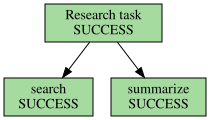

Rejected: Unknown tool


In [4]:
def build_agent(task):
    steps = validate(propose(task))
    return pt.composites.Sequence("Research task", memory=True, children=[
        Function(step["tool"], lambda step=step: tools[step["tool"]](step["argument"]))
        for step in steps])

root = build_agent("behavior trees")
root.tick_once()
assert root.status is Status.SUCCESS
assert [name for name, _ in log] == ["search", "summarize"]
display(diagram(root))
try:
    validate([{"tool": "run_arbitrary_code", "argument": "..."}])
except ValueError as error:
    print("Rejected:", error)
else:
    raise AssertionError("Unknown tools must be rejected")

## Interactive demonstration
No external tools are called: the mock tools append to a local log.

In [5]:
display(playground(lambda: build_agent("compare robot designs")))

## Key observations

The model may propose; deterministic code validates and executes. Behavior trees organize tool use but do not make model output trustworthy.

## Exercises

1. Add a result-checking condition after summarize.
2. Reject a five-step proposal and explain why bounded task size matters.

Hints and worked solutions: `exercises/README.md` and `solutions/README.md` (lesson 16).

## Summary

All sixteen lessons so far work without ROS. We can now introduce ROS as communication infrastructure for the same ideas.